Epoch 1, Loss: 206.3537
Epoch 2, Loss: 173.2726
Epoch 3, Loss: 168.7093
Epoch 4, Loss: 166.2655
Epoch 5, Loss: 164.7052
Epoch 6, Loss: 163.5735
Epoch 7, Loss: 162.6516
Epoch 8, Loss: 161.8878
Epoch 9, Loss: 161.1995
Epoch 10, Loss: 160.6000
Epoch 11, Loss: 160.1012
Epoch 12, Loss: 159.6059
Epoch 13, Loss: 159.1470
Epoch 14, Loss: 158.7211
Epoch 15, Loss: 158.2998
Epoch 16, Loss: 157.9495
Epoch 17, Loss: 157.6490
Epoch 18, Loss: 157.2754
Epoch 19, Loss: 156.9336
Epoch 20, Loss: 156.5917


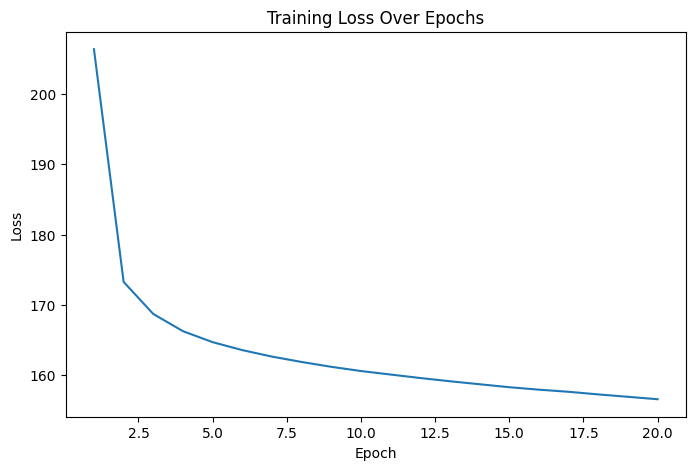

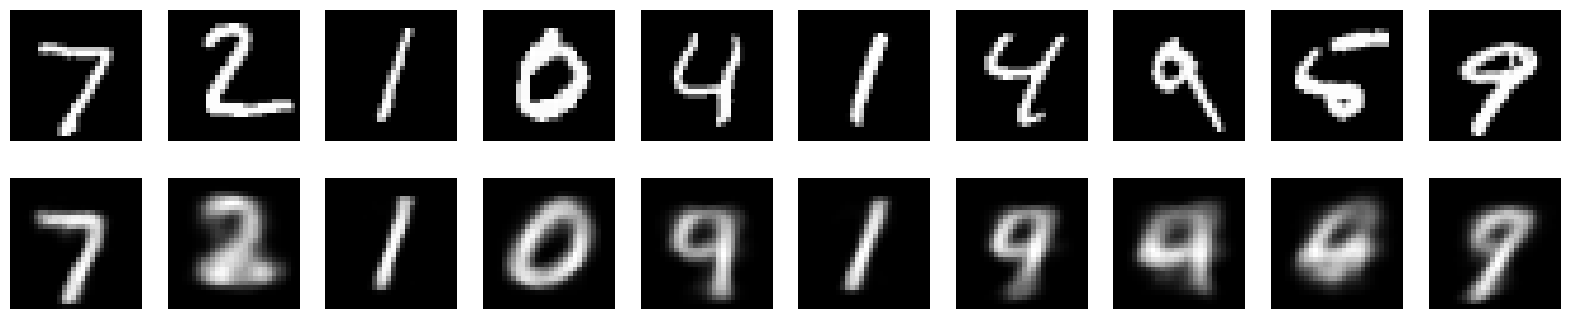

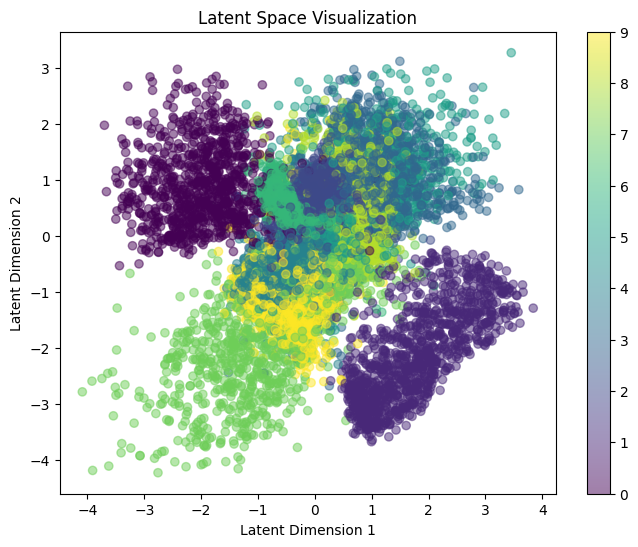

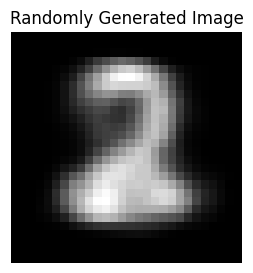

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

#____________________________________________________________________________________

# Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

#____________________________________________________________________________________

latent_dim = 2
batch_size = 128
epochs = 20

#____________________________________________________________________________________

# Encoder
encoder_inputs = Input(shape=(28, 28, 1))
x = Flatten()(encoder_inputs)
x = Dense(256, activation='relu')(x)

z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

#____________________________________________________________________________________

# Decoder
latent_inputs = Input(shape=(latent_dim,))
x = Dense(256, activation='relu')(latent_inputs)
x = Dense(28 * 28, activation='sigmoid')(x)
decoder_outputs = Reshape((28, 28, 1))(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

#____________________________________________________________________________________

# Custom VAE Loss Layer (Keras 3 Compatible)
class VAELossLayer(Layer):
    def call(self, inputs):
        x_true, x_decoded, z_mean, z_log_var = inputs

        reconstruction_loss = binary_crossentropy(
            tf.reshape(x_true, [-1, 28 * 28]),
            tf.reshape(x_decoded, [-1, 28 * 28])
        )
        reconstruction_loss = tf.reduce_mean(reconstruction_loss) * 28 * 28

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        self.add_loss(reconstruction_loss + kl_loss)
        return x_decoded

#____________________________________________________________________________________

# Build VAE
decoded = decoder(z)
vae_outputs = VAELossLayer()([encoder_inputs, decoded, z_mean, z_log_var])

vae = Model(encoder_inputs, vae_outputs, name="vae")

#____________________________________________________________________________________

vae.compile(optimizer=Adam())

#____________________________________________________________________________________

# Training Loop
history_loss = []

for epoch in range(epochs):
    hist = vae.fit(x_train, epochs=1, batch_size=batch_size, verbose=0)
    epoch_loss = hist.history['loss'][0]
    history_loss.append(epoch_loss)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

#____________________________________________________________________________________

# Plot Training Loss
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), history_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.show()

#____________________________________________________________________________________

# Reconstructed Images
z_mean_test, z_log_var_test, z_test = encoder.predict(x_test, batch_size=batch_size, verbose=0)
reconstructed_images = decoder.predict(z_test, batch_size=batch_size, verbose=0)

n = 10
plt.figure(figsize=(20,4))

for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+n+1)
    plt.imshow(reconstructed_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

#____________________________________________________________________________________

# Latent Space Visualization
if latent_dim == 2:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(z_mean_test[:,0], z_mean_test[:,1], c=y_test, cmap='viridis', alpha=0.5)
    plt.colorbar(scatter)
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title("Latent Space Visualization")
    plt.show()
else:
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(z_mean_test)

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(reduced[:,0], reduced[:,1], c=y_test, cmap='viridis', alpha=0.5)
    plt.colorbar(scatter)
    plt.title("PCA Reduced Latent Space")
    plt.show()

#____________________________________________________________________________________

# Generate Random Image
random_z = np.random.normal(size=(1, latent_dim))
generated_image = decoder.predict(random_z, verbose=0)

plt.figure(figsize=(3,3))
plt.imshow(generated_image.reshape(28,28), cmap='gray')
plt.title("Randomly Generated Image")
plt.axis('off')
plt.show()